<a href="https://colab.research.google.com/github/srinitha27/Customer-Behaviour-Analysis/blob/main/Customer_Behaviour_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/ecommerce_customer_data_custom_ratios.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [ ]:
# Display general information about the DataFrame
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


None

In [ ]:
# Display descriptive statistics of the DataFrame
display(df.describe())

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,202404.000000,250000.000000,250000.000000
mean,25004.03624,254.659512,2.998896,2725.370732,43.940528,0.497861,43.940528,0.199496
std,14428.27959,141.568577,1.414694,1442.933565,15.350246,0.499997,15.350246,0.399622
min,1.00000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


In [ ]:
# Extract time-based features from 'Purchase Date'
df['Purchase Year'] = df['Purchase Date'].dt.year
df['Purchase Month'] = df['Purchase Date'].dt.month
df['Purchase Day'] = df['Purchase Date'].dt.day
df['Purchase DayOfWeek'] = df['Purchase Date'].dt.dayofweek
df['Purchase Hour'] = df['Purchase Date'].dt.hour

# Display the first few rows with the new features
display(df.head())

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Gender,Churn,Purchase Year,Purchase Month,Purchase Day,Purchase DayOfWeek,Purchase Hour
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,Male,0,2020,9,8,1,9
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,Male,0,2022,3,5,5,12
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,Male,0,2022,5,23,0,18
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,Male,0,2020,11,12,3,13
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,Female,1,2020,11,27,4,17


In [ ]:
# Calculate Recency, Frequency, and Monetary (RFM) values

# Set a snapshot date for recency calculation (one day after the latest purchase date)
snapshot_date = df['Purchase Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency=('Purchase Date', lambda date: (snapshot_date - date.max()).days),
    Frequency=('Purchase Date', 'count'),
    Monetary=('Total Purchase Amount', 'sum')
).reset_index()

display(rfm.head())

,Customer ID,Recency,Frequency,Monetary
0,1,58,1,3491
1,2,299,3,7988
2,3,89,8,22587
3,4,127,4,8715
4,5,171,8,12524


In [ ]:
# Assign RFM scores (1-5) to each customer

# Recency: higher values mean more recent, so we need to reverse the order for scoring
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

# Frequency: higher values mean more frequent, so direct scoring
rfm['F_Score'] = pd.qcut(rfm['Frequency'], 5, labels=[1, 2, 3, 4, 5])

# Monetary: higher values mean more monetary, so direct scoring
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Combine scores into an RFM_Score string
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

display(rfm.head())

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,1,58,1,3491,5,1,1,511
1,2,299,3,7988,2,1,2,212
2,3,89,8,22587,4,5,5,455
3,4,127,4,8715,4,2,2,422
4,5,171,8,12524,3,5,3,353


In [ ]:
# Define RFM segments based on RFM scores
# For simplicity, we'll use a few common segments based on R, F, M scores
def rfm_segment(row):
    if row['R_Score'] == 5 and row['F_Score'] == 5 and row['M_Score'] == 5:
        return 'Champions'
    elif row['R_Score'] == 5 and row['F_Score'] == 5:
        return 'Loyal Customers'
    elif row['R_Score'] == 5 and row['F_Score'] == 4:
        return 'Loyal Customers'
    elif row['R_Score'] == 4 and row['F_Score'] == 5:
        return 'Loyal Customers'
    elif row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'Potential Loyalist'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'Promising'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2 and row['M_Score'] <= 2:
        return 'At Risk'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

# Display the count of customers in each segment
display(rfm['Segment'].value_counts())

,count
Segment,
Needs Attention,21407
At Risk,9788
Promising,8937
Loyal Customers,5405
Potential Loyalist,2287
Champions,1849


In [ ]:
# Merge RFM segments back to the original DataFrame to get other customer characteristics
df_merged = pd.merge(df, rfm[['Customer ID', 'Segment']], on='Customer ID')

# Profile each segment based on average age, gender distribution, and churn rate
segment_profiles = df_merged.groupby('Segment').agg(
    Avg_Age=('Customer Age', 'mean'),
    Male_Ratio=('Gender', lambda x: (x == 'Male').sum() / len(x)),
    Female_Ratio=('Gender', lambda x: (x == 'Female').sum() / len(x)),
    Avg_Churn_Rate=('Churn', 'mean')
).reset_index()

display(segment_profiles)

,Segment,Avg_Age,Male_Ratio,Female_Ratio,Avg_Churn_Rate
0,At Risk,43.445107,0.499230,0.500770,0.201363
1,Champions,43.795584,0.499736,0.500264,0.208585
2,Loyal Customers,43.811522,0.486169,0.513831,0.193887
3,Needs Attention,43.850176,0.500417,0.499583,0.197816
4,Potential Loyalist,44.778002,0.497779,0.502221,0.187736
5,Promising,44.249355,0.500265,0.499735,0.206097


In [ ]:
# Profile each segment based on top product categories
# Get top 3 product categories for each segment
top_product_categories = df_merged.groupby(['Segment', 'Product Category']).size().reset_index(name='Count')
top_product_categories = top_product_categories.sort_values(['Segment', 'Count'], ascending=False)
top_product_categories_per_segment = top_product_categories.groupby('Segment').head(3)

display(top_product_categories_per_segment)

,Segment,Product Category,Count
20,Promising,Books,16371
21,Promising,Clothing,16311
22,Promising,Electronics,11139
16,Potential Loyalist,Books,4527
17,Potential Loyalist,Clothing,4457
18,Potential Loyalist,Electronics,2944
12,Needs Attention,Books,29286
13,Needs Attention,Clothing,29250
15,Needs Attention,Home,19437
9,Loyal Customers,Clothing,12108


In [ ]:
# Profile each segment based on top payment methods
# Get top 3 payment methods for each segment
top_payment_methods = df_merged.groupby(['Segment', 'Payment Method']).size().reset_index(name='Count')
top_payment_methods = top_payment_methods.sort_values(['Segment', 'Count'], ascending=False)
top_payment_methods_per_segment = top_payment_methods.groupby('Segment').head(3)

display(top_payment_methods_per_segment)

,Segment,Payment Method,Count
21,Promising,Credit Card,21979
23,Promising,PayPal,16332
20,Promising,Cash,10897
17,Potential Loyalist,Credit Card,6038
19,Potential Loyalist,PayPal,4512
16,Potential Loyalist,Cash,2889
13,Needs Attention,Credit Card,38992
15,Needs Attention,PayPal,29023
12,Needs Attention,Cash,19481
9,Loyal Customers,Credit Card,16156


/tmp/ipykernel_3195/1357621653.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index, palette='viridis')


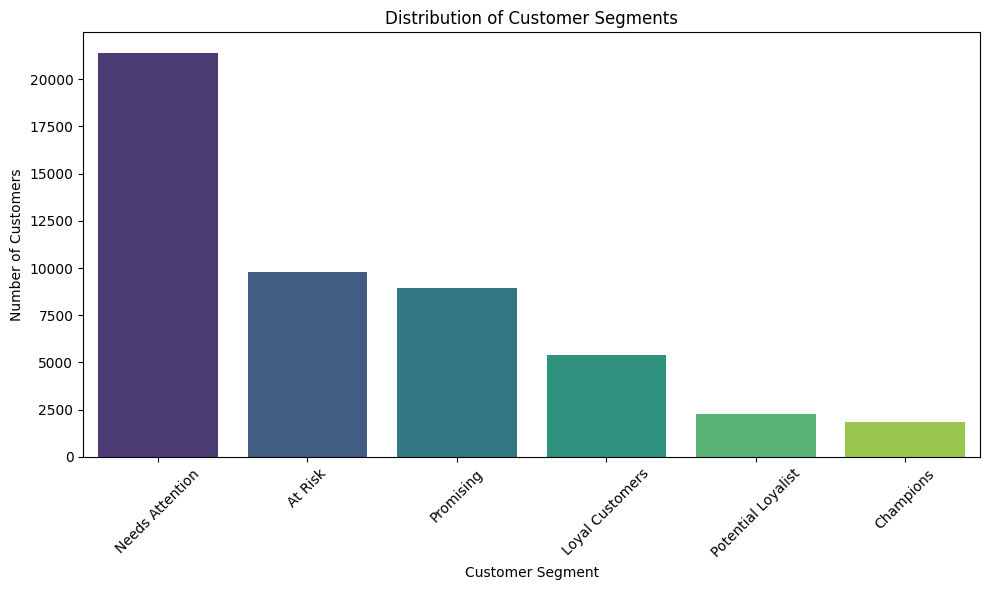

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of RFM segments
plt.figure(figsize=(10, 6))
sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index, palette='viridis')
plt.title('Distribution of Customer Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3195/1521870875.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_profiles, x='Segment', y='Avg_Age', palette='magma')


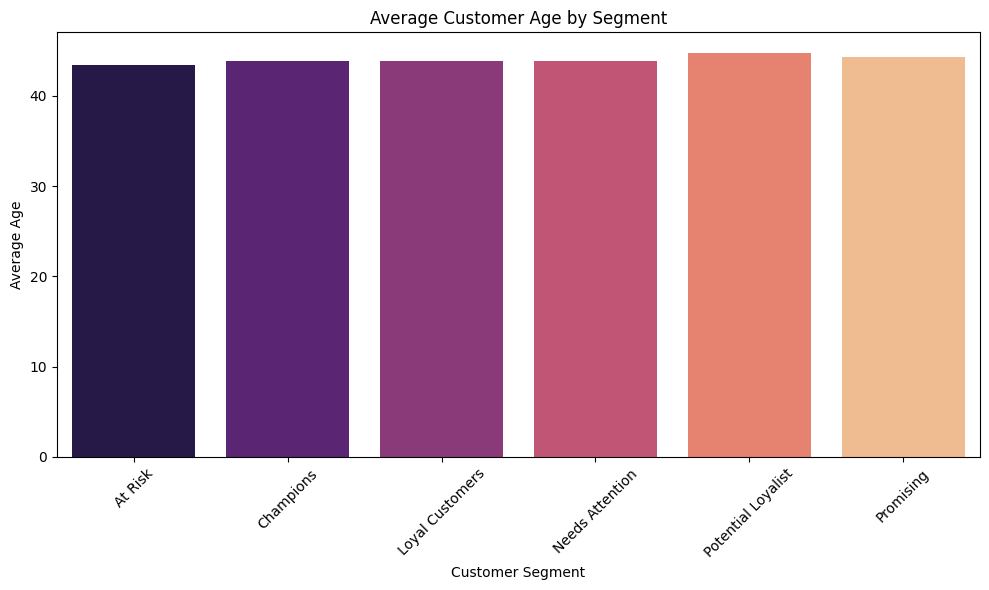

In [ ]:
# Visualize average age per segment
plt.figure(figsize=(10, 6))
sns.barplot(data=segment_profiles, x='Segment', y='Avg_Age', palette='magma')
plt.title('Average Customer Age by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Age')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3195/2881298909.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_profiles, x='Segment', y='Avg_Churn_Rate', palette='cividis')


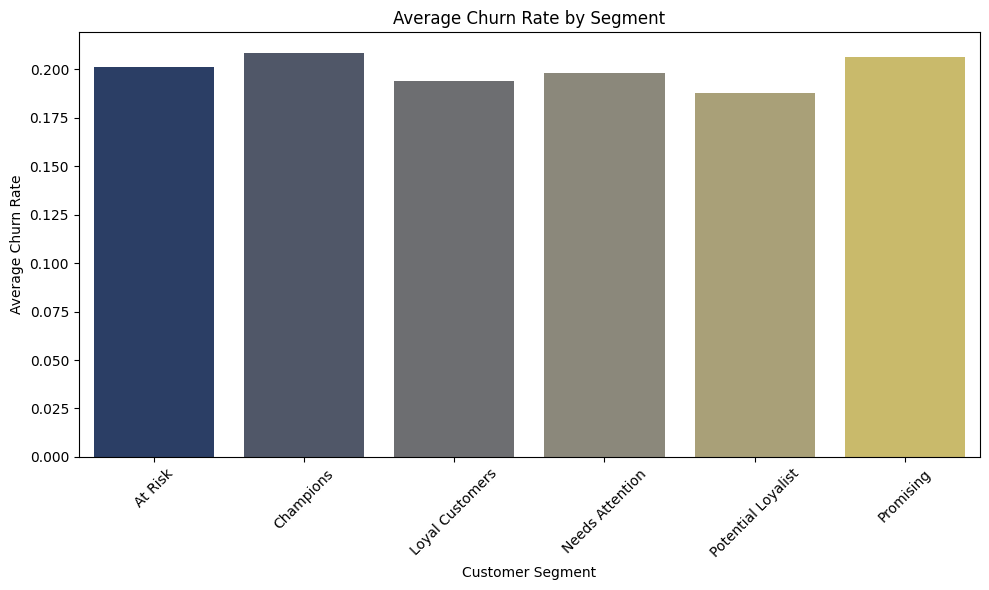

In [ ]:
# Visualize churn rate per segment
plt.figure(figsize=(10, 6))
sns.barplot(data=segment_profiles, x='Segment', y='Avg_Churn_Rate', palette='cividis')
plt.title('Average Churn Rate by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Churn Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3195/2808610029.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Purchase Month', palette='Spectral')


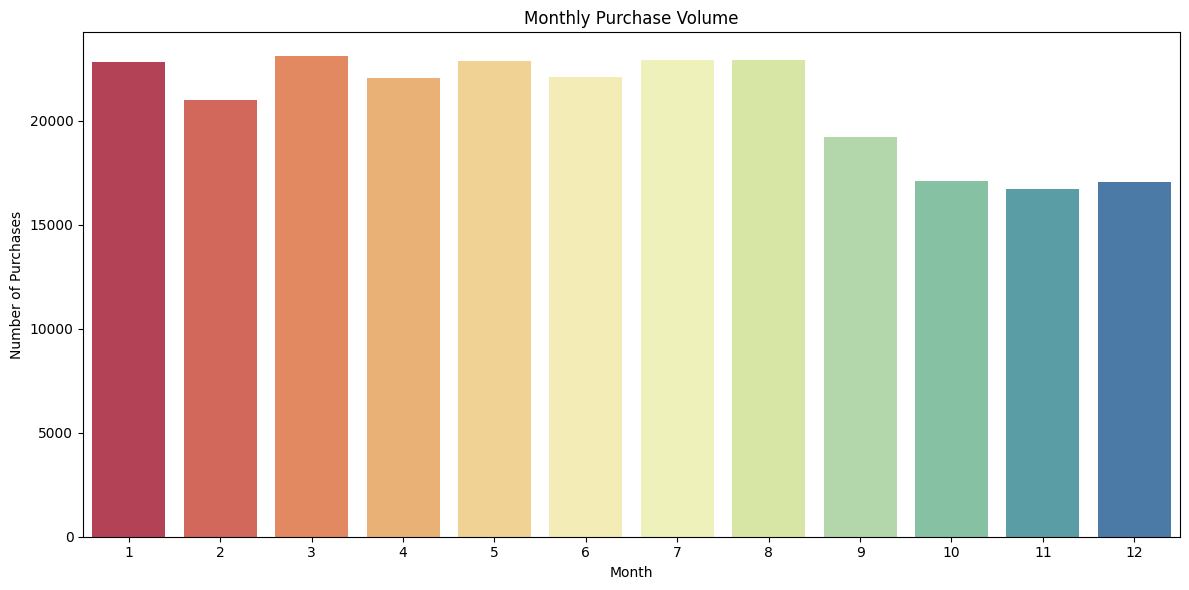

In [ ]:
# Visualize monthly purchase patterns
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Purchase Month', palette='Spectral')
plt.title('Monthly Purchase Volume')
plt.xlabel('Month')
plt.ylabel('Number of Purchases')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3195/2504472842.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Purchase Year', palette='viridis')


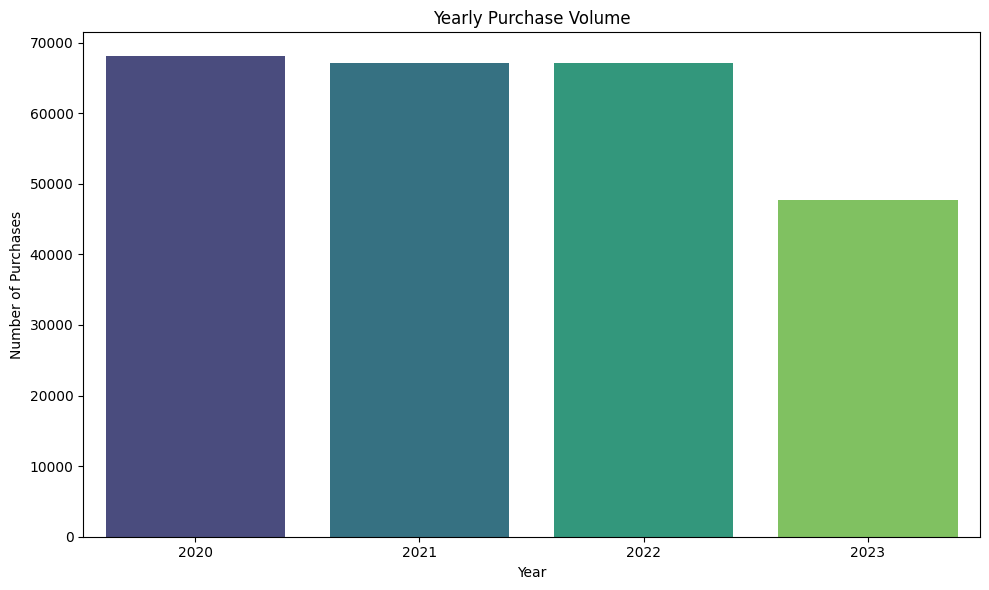

In [ ]:
# Visualize yearly purchase patterns
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Purchase Year', palette='viridis')
plt.title('Yearly Purchase Volume')
plt.xlabel('Year')
plt.ylabel('Number of Purchases')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3195/2949300295.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Product Category', order=df['Product Category'].value_counts().index, palette='rocket')


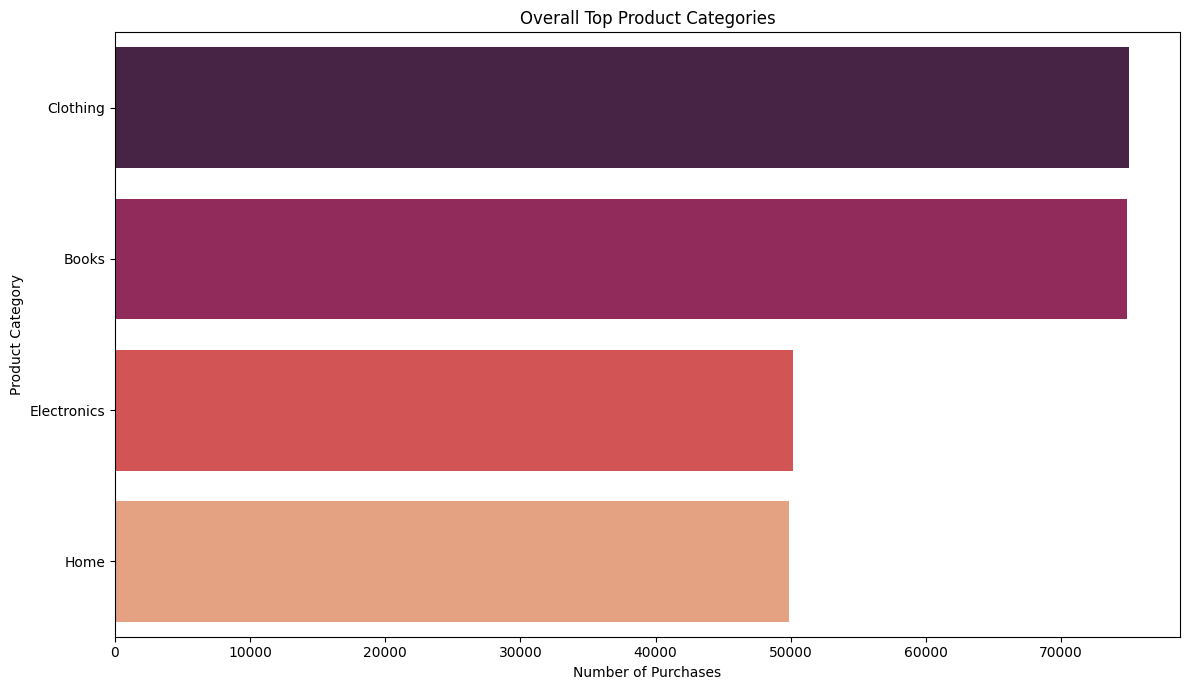

In [ ]:
# Visualize top product categories overall
plt.figure(figsize=(12, 7))
sns.countplot(data=df, y='Product Category', order=df['Product Category'].value_counts().index, palette='rocket')
plt.title('Overall Top Product Categories')
plt.xlabel('Number of Purchases')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3195/1361320198.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Payment Method', order=df['Payment Method'].value_counts().index, palette='mako')


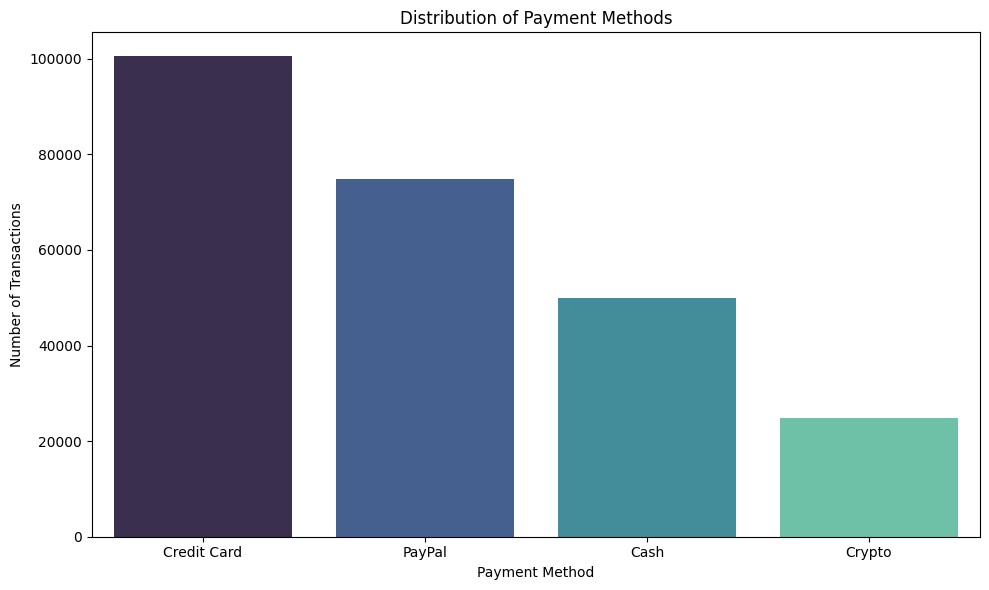

In [ ]:
# Visualize distribution of payment methods
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Payment Method', order=df['Payment Method'].value_counts().index, palette='mako')
plt.title('Distribution of Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

In [ ]:
# Convert 'Purchase Date' to datetime objects
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Display data types after conversion
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Customer ID            250000 non-null  int64         
 1   Purchase Date          250000 non-null  datetime64[ns]
 2   Product Category       250000 non-null  object        
 3   Product Price          250000 non-null  int64         
 4   Quantity               250000 non-null  int64         
 5   Total Purchase Amount  250000 non-null  int64         
 6   Payment Method         250000 non-null  object        
 7   Customer Age           250000 non-null  int64         
 8   Returns                202404 non-null  float64       
 9   Customer Name          250000 non-null  object        
 10  Age                    250000 non-null  int64         
 11  Gender                 250000 non-null  object        
 12  Churn                  250000 non-null  int6

None

In [ ]:
# Check for missing values in 'Returns' column
display(df['Returns'].isnull().sum())

# For simplicity, fill missing 'Returns' values with 0 (assuming NaN means no return)
df['Returns'].fillna(0, inplace=True)

# Verify that missing values have been handled
display(df['Returns'].isnull().sum())

np.int64(47596)

/tmp/ipykernel_3195/2281085991.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Returns'].fillna(0, inplace=True)


np.int64(0)

In [ ]:
# Check if 'Customer Age' and 'Age' columns are identical
display((df['Customer Age'] == df['Age']).all())

# If they are identical, drop one of them (e.g., 'Age')
if (df['Customer Age'] == df['Age']).all():
    df.drop('Age', axis=1, inplace=True)
    print("Dropped 'Age' column as it was a duplicate of 'Customer Age'.")

# Display the columns after potential drop
display(df.columns)

np.True_

Dropped 'Age' column as it was a duplicate of 'Customer Age'.


Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Gender', 'Churn'],
      dtype='object')